# EDA: отзывы и геоданные (Olist)

Распределение оценок, длина текста отзыва, выборочный просмотр геолокаций.

Данные: `../data/raw/`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
DATA = "../data/raw/"

In [2]:
reviews = pd.read_csv(f"{DATA}olist_order_reviews_dataset.csv")
geo = pd.read_csv(f"{DATA}olist_geolocation_dataset.csv")
print("reviews", reviews.shape)
print("geo", geo.shape)
reviews.head()

reviews (99224, 7)
geo (1000163, 5)


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


## Распределение оценок (review_score)

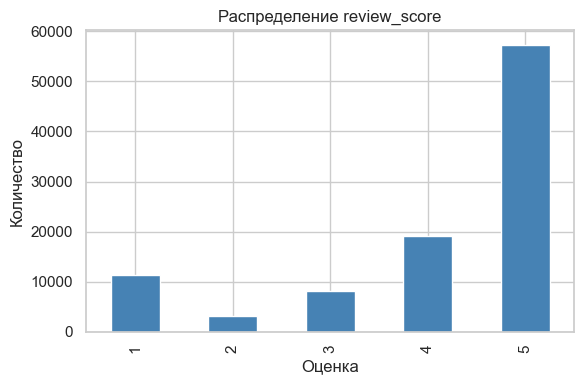

is_satisfied
1    0.77068
0    0.22932
Name: proportion, dtype: float64


In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
reviews["review_score"].value_counts().sort_index().plot(kind="bar", ax=ax, color="steelblue")
ax.set_xlabel("Оценка")
ax.set_ylabel("Количество")
ax.set_title("Распределение review_score")
plt.tight_layout()
plt.show()

reviews["is_satisfied"] = (reviews["review_score"] >= 4).astype(int)
print(reviews["is_satisfied"].value_counts(normalize=True))

## Текст отзыва: длина и пропуски

Доля пустых отзывов: 0.5870253164556962


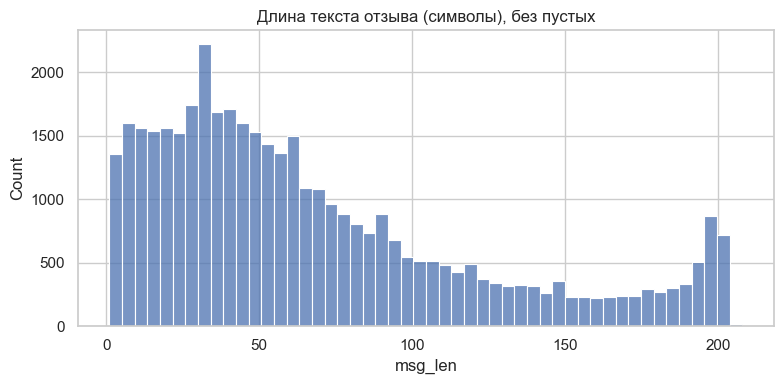

In [4]:
msg = reviews["review_comment_message"].fillna("")
reviews["msg_len"] = msg.str.len()
print("Доля пустых отзывов:", (msg == "").mean())

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(reviews.loc[reviews["msg_len"] > 0, "msg_len"], bins=50, ax=ax)
ax.set_title("Длина текста отзыва (символы), без пустых")
plt.tight_layout()
plt.show()

## Геолокации: выборка точек по штату

В `reviews_preprocess.py` координаты агрегируются по префиксу ZIP; здесь — обзор плотности по `geolocation_state`.

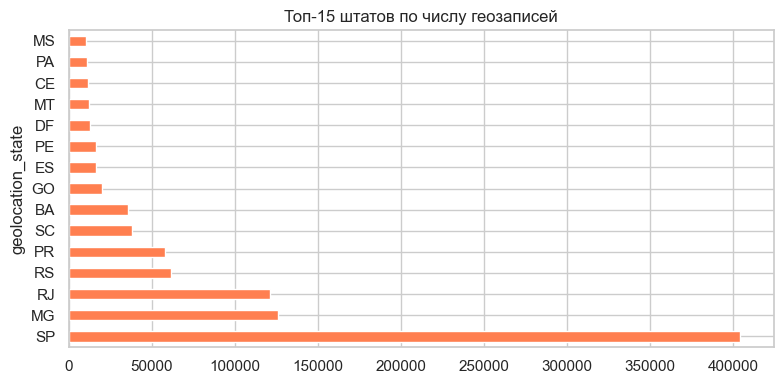

In [5]:
state_counts = geo["geolocation_state"].value_counts().head(15)
fig, ax = plt.subplots(figsize=(8, 4))
state_counts.plot(kind="barh", ax=ax, color="coral")
ax.set_title("Топ-15 штатов по числу геозаписей")
plt.tight_layout()
plt.show()

## География: выборка координат

Полный `olist_geolocation_dataset` очень большой, для наглядности — случайная выборка точек (широта / долгота).

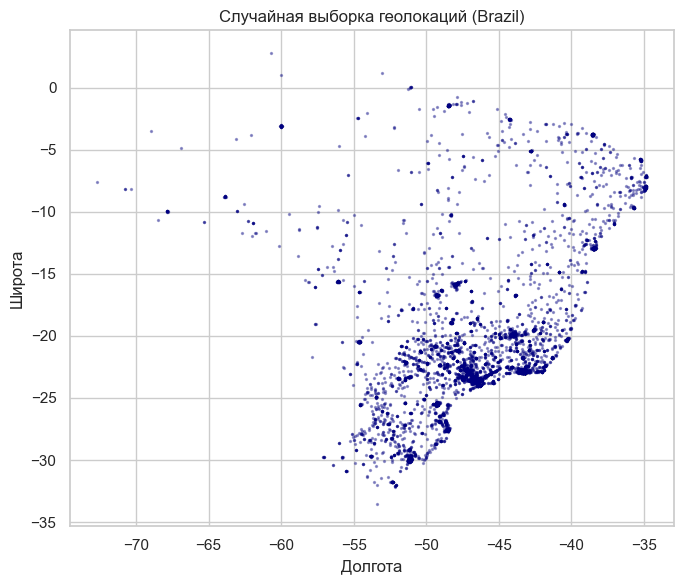

In [6]:
sample_geo = geo.sample(n=min(8000, len(geo)), random_state=42)
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(sample_geo["geolocation_lng"], sample_geo["geolocation_lat"], s=2, alpha=0.35, c="navy")
ax.set_xlabel("Долгота")
ax.set_ylabel("Широта")
ax.set_title("Случайная выборка геолокаций (Brazil)")
plt.tight_layout()
plt.show()

## Связь с ML

Текст отзыва обрабатывается в `reviews_preprocess.py` (pandas + sklearn): токенизация, стоп-слова (EN + PT), TF-IDF. В финальный parquet попадают `review_text_length`, `tfidf_norm` и агрегаты по гео.

## Дополнительный EDA для `reviews_preprocess.py`

Здесь проверяем, какие признаки из блока отзывов и гео действительно полезно вынести в пайплайн: наличие текста, длину текста, скорость ответа на отзыв и усреднённую дистанцию между покупателем и продавцом.

In [7]:
import numpy as np

_PT_STOPWORDS = {
    "de", "a", "o", "que", "e", "do", "da", "em", "um", "para",
    "com", "uma", "os", "no", "se", "na", "por", "mais", "as",
    "dos", "como", "mas", "ao", "ele", "das", "seu", "sua",
    "ou", "quando", "muito", "nos", "ja", "eu", "tambem", "so",
    "pelo", "pela", "ate", "isso", "ela", "entre", "depois",
    "sem", "mesmo", "aos", "seus", "quem", "nas", "me", "esse",
    "eles", "voce", "essa", "num", "nem", "suas", "meu",
    "minha", "numa", "pelos", "elas", "havia", "seja", "qual",
    "sera", "tenho", "lhe", "deles", "essas", "esses",
    "pelas", "este", "dele", "tu", "te", "voces", "vos", "lhes",
    "meus", "minhas", "teu", "tua", "teus", "tuas", "nosso",
    "nossa", "nossos", "nossas", "dela", "delas", "esta", "estes",
    "estas", "aquele", "aquela", "aqueles", "aquelas", "isto",
    "aquilo", "estou", "estamos", "estao", "estive",
}

reviews_eda = reviews.copy()
reviews_eda["review_comment_title"] = reviews_eda["review_comment_title"].fillna("")
reviews_eda["review_comment_message"] = reviews_eda["review_comment_message"].fillna("")
reviews_eda["full_text"] = (
    reviews_eda["review_comment_title"].str.strip() + " " + reviews_eda["review_comment_message"].str.strip()
).str.strip().str.lower()
reviews_eda["is_satisfied"] = (reviews_eda["review_score"] >= 4).astype(int)
reviews_eda["has_title"] = (reviews_eda["review_comment_title"] != "").astype(int)
reviews_eda["has_message"] = (reviews_eda["review_comment_message"] != "").astype(int)

def _script_token_count(text: str) -> int:
    return sum(1 for t in text.split() if t not in _PT_STOPWORDS and len(t) > 1)

reviews_eda["token_count"] = reviews_eda["full_text"].apply(_script_token_count)
reviews_eda["review_creation_date"] = pd.to_datetime(reviews_eda["review_creation_date"], errors="coerce")
reviews_eda["review_answer_timestamp"] = pd.to_datetime(reviews_eda["review_answer_timestamp"], errors="coerce")
reviews_eda["response_hours"] = (
    reviews_eda["review_answer_timestamp"] - reviews_eda["review_creation_date"]
) / pd.Timedelta(hours=1)


In [8]:
text_summary = reviews_eda.groupby("is_satisfied").agg(
    has_title_rate=("has_title", "mean"),
    has_message_rate=("has_message", "mean"),
    median_token_count=("token_count", "median"),
    median_response_hours=("response_hours", "median"),
).round(2)
print("Сводка по текстовым признакам и времени ответа:")
display(text_summary)


Сводка по текстовым признакам и времени ответа:


,has_title_rate,has_message_rate,median_token_count,median_response_hours
is_satisfied,,,,
0,0.14,0.63,5.0,39.31
1,0.11,0.35,0.0,40.42


In [9]:
geo_raw = pd.read_csv(f"{DATA}olist_geolocation_dataset.csv")
sellers = pd.read_csv(f"{DATA}olist_sellers_dataset.csv", usecols=["seller_id", "seller_zip_code_prefix"])
orders_geo = pd.read_csv(f"{DATA}olist_orders_dataset.csv", usecols=["order_id", "customer_id"])
items_geo = pd.read_csv(f"{DATA}olist_order_items_dataset.csv", usecols=["order_id", "seller_id"])
customers_geo = pd.read_csv(f"{DATA}olist_customers_dataset.csv", usecols=["customer_id", "customer_zip_code_prefix"])


In [10]:
geo_avg = (
    geo_raw.groupby("geolocation_zip_code_prefix")[["geolocation_lat", "geolocation_lng"]]
    .mean()
    .rename(columns={"geolocation_lat": "lat", "geolocation_lng": "lng"})
    .reset_index()
)

sellers_geo = sellers.merge(
    geo_avg,
    left_on="seller_zip_code_prefix",
    right_on="geolocation_zip_code_prefix",
    how="left",
).rename(columns={"lat": "seller_lat", "lng": "seller_lng"})[["seller_id", "seller_lat", "seller_lng"]]

customers_geo = customers_geo.merge(
    geo_avg,
    left_on="customer_zip_code_prefix",
    right_on="geolocation_zip_code_prefix",
    how="left",
).rename(columns={"lat": "customer_lat", "lng": "customer_lng"})[["customer_id", "customer_lat", "customer_lng"]]

geo_pairs = (
    items_geo.merge(orders_geo, on="order_id", how="left")
    .merge(sellers_geo, on="seller_id", how="left")
    .merge(customers_geo, on="customer_id", how="left")
)

In [11]:
lat1 = np.radians(geo_pairs["seller_lat"])
lon1 = np.radians(geo_pairs["seller_lng"])
lat2 = np.radians(geo_pairs["customer_lat"])
lon2 = np.radians(geo_pairs["customer_lng"])

dlat = lat2 - lat1
dlon = lon2 - lon1

a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
geo_pairs["distance_km"] = 6371 * 2 * np.arcsin(np.sqrt(a))

order_distance = (
    geo_pairs.groupby("order_id")["distance_km"]
    .mean()
    .rename("avg_seller_distance_km")
    .reset_index()
)

In [12]:
reviews_geo = reviews_eda.merge(order_distance, on="order_id", how="left")
geo_summary = (
    reviews_geo.groupby("is_satisfied")["avg_seller_distance_km"]
    .median()
    .round(1)
    .rename("median_distance_km")
)
print("Медианная дистанция продавец-покупатель по классам:")
display(geo_summary.to_frame())


Медианная дистанция продавец-покупатель по классам:


,median_distance_km
is_satisfied,
0,471.2
1,423.2


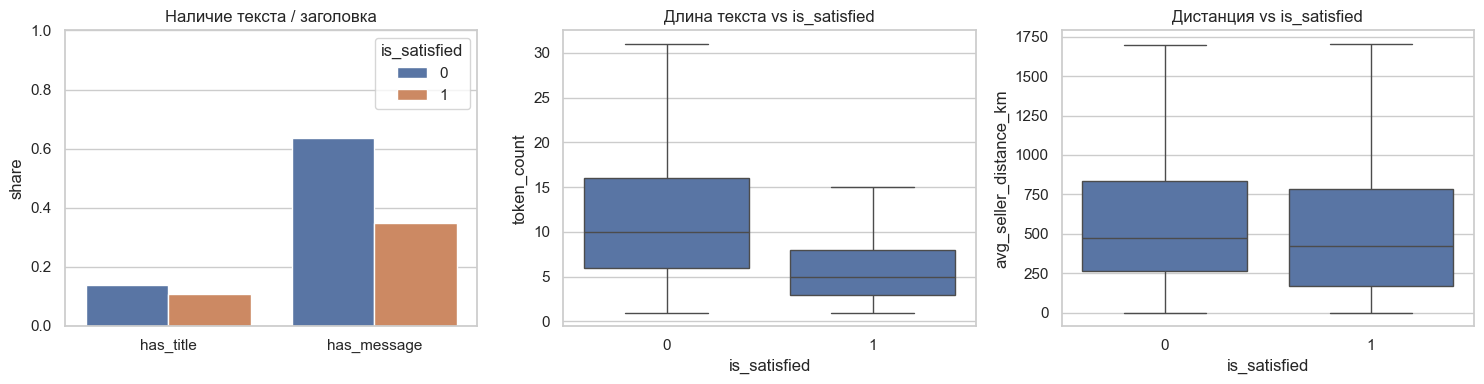

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
text_presence = (
    reviews_eda.groupby("is_satisfied")[["has_title", "has_message"]]
    .mean()
    .reset_index()
    .melt(id_vars="is_satisfied", var_name="feature", value_name="share")
)
sns.barplot(data=text_presence, x="feature", y="share", hue="is_satisfied", ax=axes[0])
axes[0].set_title("Наличие текста / заголовка")
axes[0].set_ylim(0, 1)
axes[0].set_xlabel("")
axes[0].set_ylabel("share")

sns.boxplot(
    data=reviews_eda[reviews_eda["token_count"] > 0],
    x="is_satisfied",
    y="token_count",
    showfliers=False,
    ax=axes[1],
)
axes[1].set_title("Длина текста vs is_satisfied")
axes[1].set_xlabel("is_satisfied")
axes[1].set_ylabel("token_count")

sns.boxplot(
    data=reviews_geo.dropna(subset=["avg_seller_distance_km"]),
    x="is_satisfied",
    y="avg_seller_distance_km",
    showfliers=False,
    ax=axes[2],
)
axes[2].set_title("Дистанция vs is_satisfied")
axes[2].set_xlabel("is_satisfied")
axes[2].set_ylabel("avg_seller_distance_km")

plt.tight_layout()
plt.show()


In [14]:
candidate_features = pd.Series(
    {
        "has_message": "добавить отдельный флаг наличия текста",
        "has_title": "добавить отдельный флаг наличия заголовка",
        "token_count / review_text_length": "оставить как компактную текстовую характеристику",
        "response_hours": "кандидат на новый временной признак по отзывам",
        "avg_seller_distance_km": "сохранить как order-level гео-признак",
    }
)
display(candidate_features.to_frame("Почему полезно"))


,Почему полезно
has_message,добавить отдельный флаг наличия текста
has_title,добавить отдельный флаг наличия заголовка
token_count / review_text_length,оставить как компактную текстовую характеристику
response_hours,кандидат на новый временной признак по отзывам
avg_seller_distance_km,сохранить как order-level гео-признак


## Обоснование параметров TF-IDF и стоп-слов PT

Проверяем, что параметры `min_df=5`, `max_features=512` и объединённый список стоп-слов EN+PT не теряют сигнала, а также что нормализация диакритики согласует корпус со стоп-словами.

In [15]:
import unicodedata
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer

def strip_accents(text: str) -> str:
    return "".join(
        ch for ch in unicodedata.normalize("NFD", text)
        if unicodedata.category(ch) != "Mn"
    )

full_text_norm = (
    reviews["review_comment_title"].fillna("")
    + " "
    + reviews["review_comment_message"].fillna("")
).str.lower().map(strip_accents)

tfidf_stopwords = sorted({w for w in (set(ENGLISH_STOP_WORDS) | _PT_STOPWORDS) if len(w) >= 2})

for min_df in (2, 5, 10, 20):
    vec = TfidfVectorizer(min_df=min_df, max_features=2048, stop_words=tfidf_stopwords,
                          token_pattern=r"(?u)\b\w{2,}\b")
    vec.fit(full_text_norm)
    print(f"min_df={min_df:>3}  vocab_size={len(vec.vocabulary_)}")

min_df=  2  vocab_size=2048
min_df=  5  vocab_size=2048
min_df= 10  vocab_size=2048
min_df= 20  vocab_size=1408


In [16]:
vec_final = TfidfVectorizer(
    min_df=5, max_features=512, stop_words=tfidf_stopwords,
    token_pattern=r"(?u)\b\w{2,}\b",
)
tfidf_matrix = vec_final.fit_transform(full_text_norm)
print(f"Итоговый словарь: {len(vec_final.vocabulary_)} термов (cap = 512)")

tfidf_norm = np.sqrt(np.asarray(tfidf_matrix.power(2).sum(axis=1)).ravel())
reviews_tfidf = reviews.assign(tfidf_norm=tfidf_norm,
                               is_satisfied=(reviews["review_score"] >= 4).astype(int))
print("Доля строк с tfidf_norm == 0:", (reviews_tfidf["tfidf_norm"] == 0).mean().round(3))
print("Медиана tfidf_norm по классам:")
display(reviews_tfidf.groupby("is_satisfied")["tfidf_norm"].median().round(3))

Итоговый словарь: 512 термов (cap = 512)
Доля строк с tfidf_norm == 0: 0.577
Медиана tfidf_norm по классам:


is_satisfied
0    1.0
1    0.0
Name: tfidf_norm, dtype: float64

In [17]:
full_text_raw_lower = (
    reviews["review_comment_title"].fillna("")
    + " "
    + reviews["review_comment_message"].fillna("")
).str.lower()

tokens_raw = Counter()
for toks in full_text_raw_lower.str.split():
    tokens_raw.update(toks)

tokens_norm = Counter()
for toks in full_text_norm.str.split():
    tokens_norm.update(toks)

top_raw = pd.Series(dict(tokens_raw.most_common(20)), name="count_raw")
top_norm = pd.Series(dict(tokens_norm.most_common(20)), name="count_norm_ascii")

print("Топ-20 токенов ДО удаления диакритики:")
display(top_raw.to_frame())
print("Топ-20 токенов ПОСЛЕ удаления диакритики (совпадает со стоп-словами PT):")
display(top_norm.to_frame())

pt_hits_raw = sum(tokens_raw.get(w, 0) for w in _PT_STOPWORDS)
pt_hits_norm = sum(tokens_norm.get(w, 0) for w in _PT_STOPWORDS)
print(f"Попаданий PT-стоп-слов: сырой текст={pt_hits_raw}, после NFD={pt_hits_norm}")
print("Нормализация диакритики критична: иначе `não / está` не попадают в стоп-лист.")

Топ-20 токенов ДО удаления диакритики:


,count_raw
o,18978
produto,16670
e,15728
a,12293
de,11565
do,11297
não,11297
muito,8447
que,8319
entrega,5878


Топ-20 токенов ПОСЛЕ удаления диакритики (совпадает со стоп-словами PT):


,count_norm_ascii
e,20262
o,18979
produto,16670
nao,12755
a,12486
de,11569
do,11298
muito,8447
que,8333
entrega,5883


Попаданий PT-стоп-слов: сырой текст=153195, после NFD=164617
Нормализация диакритики критична: иначе `não / está` не попадают в стоп-лист.


### Вывод для пайплайна

Дополнительный EDA показывает, что в `reviews_preprocess.py` имеет смысл отделить сам факт наличия текста от его длины: доля пустых отзывов велика, поэтому флаги `has_message` и `has_title` могут быть полезнее, чем только TF-IDF-норма. Кроме того, `response_hours` и `avg_seller_distance_km` выглядят как интерпретируемые компактные признаки, которые можно безопасно сохранить в parquet рядом с уже существующими текстовыми и гео-фичами.